In [2]:
import os
seed_index=503
folder_path = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"+str(seed_index)
if not os.path.exists(folder_path):  #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(folder_path)
f=folder_path+"/"

In [3]:
import numpy as np
import torch

# Load input data arrays from .npy files
x = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/yc_21.npy")
y2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")

####################
# Alternative data loading and cleaning code (commented out):
# y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
# nanindex=np.where(np.isnan(y[:,205]))
# x=np.delete(x,nanindex,axis=0)
# y=np.delete(y,nanindex,axis=0)
# y2=np.delete(y2,nanindex,axis=0)
###################

# Initialize a new array for normalized x data with shape (samples, 216, 21, 21, 8)
xn = np.full((x.shape[0], 216, 21, 21, 8), np.nan)

# Normalize each channel (8 channels) of x data to range [0, 1]
for i in range(8):
    # Calculate min and max values for current channel
    xmin = np.nanmin(x[:, :, :, :, i])
    xmax = np.nanmax(x[:, :, :, :, i])
    # Apply min-max normalization to current channel
    xn[:, :, :, :, i] = (x[:, :, :, :, i] - xmin) / (xmax - xmin)

# Replace any remaining NaN values with 0 in the normalized x array
xn = np.nan_to_num(xn, nan=0)

# Normalize y data to range [0, 1] using min-max scaling
ymin = np.nanmin(y)
ymax = np.nanmax(y)
yn = (y - ymin) / (ymax - ymin)

# Normalize y2 data to range [0, 1] using min-max scaling
y2min = np.nanmin(y2)
y2max = np.nanmax(y2)
y2n = (y2 - y2min) / (y2max - y2min)

In [4]:
# Get the total number of samples in the dataset
len_data = x.shape[0]

# Generate random permutation of indices for shuffling the data
shuffled_indices = np.random.permutation(len_data)

# Split indices into training (70%), validation (10%), and test (20%) sets
train_idx = shuffled_indices[:int(0.7*len_data)]
val_idx = shuffled_indices[int(0.7*len_data):int(0.8*len_data)]
test_idx = shuffled_indices[int(0.8*len_data):]

# Transpose x array to change dimension order for CNN input (channels first)
x = np.transpose(xn, (0, 4, 1, 2, 3))

# Add an extra dimension to y to match expected shape for model output
y = np.expand_dims(yn, axis=-1)

# Slice y to select specific time steps (from index 6 onwards)
y = y[:, 6:, :]

# Slice y2 to select specific time steps (from index 6 onwards)
y2 = y2n[:, :, 6:, :, :]

# Create training dataset using training indices
x_train = x[train_idx, :, :, :, :]
y_train = y[train_idx, :, :]
y2_train = y2[train_idx, :, :]

# Create validation dataset using validation indices
x_val = x[val_idx, :, :, :, :]
y_val = y[val_idx, :, :]
y2_val = y2[val_idx, :, :]

# Create test dataset using test indices
x_test = x[test_idx, :, :, :, :]
y_test = y[test_idx, :, :]
y2_test = y2[test_idx, :, :]

# Print shapes to verify dataset dimensions
print(x_train.shape, y_train.shape, y2_test.shape, x_val.shape)

# Print value ranges to confirm all data is properly normalized (0-1 range)
print(x.min(), x.max(), y.min(), y.max(), y2.min(), y2.max())  # make sure they are all maxmin

(515, 8, 216, 21, 21) (515, 210, 1) (148, 1, 210, 21, 21) (74, 8, 216, 21, 21)
0.0 1.0 0.0 1.0 0.0 1.0


In [5]:
y2_max=1;y2_min=0
y1_max=0.2324; y1_min=-0.2055 
# y1_max=0.1609; y1_min=-0.1125 

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn import Conv1d, Conv2d, Conv3d, Flatten, Linear
from torch.nn import MaxPool1d, MaxPool2d, MaxPool3d
from torch.nn.functional import relu
from torch.optim import SGD, Adam
from torch.nn import L1Loss
# from ignite.metrics import SSIM
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import OrderedDict
from torch import nn, optim
from torchmetrics.functional import r2_score
import torch.optim as optim
import torch.distributed as dist
import torch.multiprocessing as mp
import numpy as np
from torch.nn import init
import random
import os

# Define weight initialization function for neural network layers
def weigth_init(m):
    # Initialize Conv2d layers with Xavier uniform distribution for weights, constant for biases
    if isinstance(m, nn.Conv2d):
        init.xavier_uniform_(m.weight.data)
        init.constant_(m.bias.data, 0.1)
    # Initialize BatchNorm2d layers with weights=1 and biases=0
    elif isinstance(m, nn.BatchNorm2d):
        m.weight.data.fill_(1)
        m.bias.data.zero_()
    # Initialize Linear layers with normal distribution for weights, zero for biases
    elif isinstance(m, nn.Linear):
        m.weight.data.normal_(0, 0.01)
        m.bias.data.zero_()

# Function to set random seeds for reproducibility across all libraries
def seed_torch(seed=1029):
    # Set random seed for Python's built-in random module
    random.seed(seed)
    # Set environment variable to disable hash randomization
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Set random seed for NumPy
    np.random.seed(seed)
    # Set random seed for PyTorch CPU operations
    torch.manual_seed(seed)
    # Set random seed for current CUDA device
    torch.cuda.manual_seed(seed)
    # Set random seed for all CUDA devices (multi-GPU setups)
    torch.cuda.manual_seed_all(seed)
    # Disable cuDNN benchmarking for deterministic behavior
    torch.backends.cudnn.benchmark = False
    # Enable cuDNN deterministic mode for reproducible results
    torch.backends.cudnn.deterministic = True

In [7]:
# Custom Dataset class for handling input data and multiple target outputs
class CustomDataset(Dataset):
    def __init__(self, x, y1, y2):
        # Convert input numpy arrays to PyTorch tensors with float32 precision
        self.x = torch.tensor(x, dtype=torch.float32)  # Input features
        self.y1 = torch.tensor(y1, dtype=torch.float32)  # First target output
        self.y2 = torch.tensor(y2, dtype=torch.float32)  # Second target output
        
    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.x)

    def __getitem__(self, idx):
        # Return a single data sample (input, target1, target2) at the given index
        return self.x[idx], self.y1[idx], self.y2[idx]


# 3D CNN regression model with attention mechanism and dual outputs
class RegressionModel3(torch.nn.Module):
    def __init__(self):
        super(RegressionModel3, self).__init__()

        # 3D convolutional layers for feature extraction
        self.c0 = nn.Conv3d(in_channels=8, out_channels=128, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c1 = nn.Conv3d(in_channels=128, out_channels=512, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c2 = nn.Conv3d(in_channels=512, out_channels=1024, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c3 = nn.Conv3d(in_channels=1024, out_channels=1, kernel_size=(1,3,3), padding=(0,1,1), stride=1)
        
        # Fully connected layers for regression output
        self.l1 = nn.Linear(441, 484)
        self.l2 = nn.Linear(484, 968)
        self.l3 = nn.Linear(968, 1)
        
        # Regularization and normalization layers
        self.dropout = nn.Dropout(p=0.1)
        self.max_pooling_layer3d = MaxPool3d(1)
        
        # Activation functions
        self.leakyrelu = nn.LeakyReLU(0.1)
        self.relu = nn.ReLU()
        
        # Attention mechanism components
        self.conv_am = nn.Conv3d(in_channels=2, out_channels=1, kernel_size=(1,3,3), 
                                stride=1, padding=(0,1,1), bias=False)
        self.sg = nn.Sigmoid()
        
        # Batch normalization layers
        self.bn0 = nn.BatchNorm3d(128)
        self.bn1 = nn.BatchNorm3d(512)
        self.bn2 = nn.BatchNorm3d(1024)
        self.bn3 = nn.BatchNorm3d(1024)
        
    
    def forward(self, x):
        # Feature extraction through convolutional blocks
        x = self.leakyrelu(self.c0(x))
        x = self.dropout(x)
        x = self.max_pooling_layer3d(x)
        x = self.bn0(x)
        
        x = self.leakyrelu(self.c1(x))
        x = self.dropout(x)
        x = self.max_pooling_layer3d(x)
        x = self.bn1(x)
       
        x = self.leakyrelu(self.c2(x))
        x = self.dropout(x)
        x = self.max_pooling_layer3d(x)
        x = self.bn2(x)

        # Attention mechanism: combine max and mean pooling
        max_out, _ = torch.max(x, dim=1, keepdim=True)  # Max pooling along channel dimension
        mean_out = torch.mean(x, dim=1, keepdim=True)   # Average pooling along channel dimension
        am_out = torch.cat((max_out, mean_out), dim=1)  # Concatenate max and mean features
        
        # Process attention weights through convolutional layer and sigmoid
        am_out = self.conv_am(am_out)
        am_out = self.sg(am_out)  # Generate attention weights between 0-1
        self.am_out = am_out  # Store attention weights for potential analysis
        
        # Apply attention weights to features and continue processing
        y2 = am_out  # Second output: attention weights
        x = self.bn3(x)
        x = x * am_out  # Apply attention modulation
        
        # Final convolutional processing
        x = self.max_pooling_layer3d(x)
        x = self.leakyrelu(self.c3(x))
        x = self.dropout(x)
        x = self.max_pooling_layer3d(x)
       
        # Flatten and process through fully connected layers
        x = x.squeeze(dim=1)  # Remove channel dimension
        x = torch.flatten(x, start_dim=2)  # Flatten spatial dimensions
        x = self.leakyrelu(self.l1(x))
        x = self.dropout(x)
        x = self.leakyrelu(self.l2(x))
        x = self.dropout(x)
        y1 = self.leakyrelu(self.l3(x))  # First output: regression prediction

        # Return both regression output (y1) and attention weights (y2)
        return y1, y2

In [8]:
# Set batch size for data loading
batch_size = 4

# Create DataLoader instances for training, validation, test, and full datasets
# DataLoader handles batching, shuffling, and parallel data loading
train_dataloader = DataLoader(CustomDataset(x_train, y_train, y2_train), 
                             batch_size=batch_size, shuffle=False)  # Training data loader
val_dataloader = DataLoader(CustomDataset(x_val, y_val, y2_val), 
                           batch_size=batch_size, shuffle=False)    # Validation data loader
test_dataloader = DataLoader(CustomDataset(x_test, y_test, y2_test), 
                            batch_size=batch_size, shuffle=False)   # Test data loader
xy_dataloader = DataLoader(CustomDataset(x, y, y2), 
                          batch_size=batch_size, shuffle=False)     # Full dataset loader (train + val + test)

# Save DataLoader objects to disk for later use (reproducibility and deployment)
# Note: 'f' variable should contain the directory path for file saving
torch.save(test_dataloader, f + "test_dataloader.pth")   # Save test data loader
torch.save(val_dataloader, f + "val_dataloader.pth")     # Save validation data loader
torch.save(train_dataloader, f + "train_dataloader.pth") # Save training data loader
torch.save(xy_dataloader, f + "xy_dataloader.pth")       # Save complete dataset loader

In [9]:
# Set random seed for reproducibility and initialize device (GPU if available)
seed_torch(seed_index)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the regression model
model = RegressionModel3()

# Enable multi-GPU training if multiple GPUs are available
if torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = torch.nn.DataParallel(model).to(device)  # Wrap model for multi-GPU training

# Move model to appropriate device (GPU/CPU)
model.to(device)

# Apply custom weight initialization to all model parameters
model.apply(weigth_init)

# Define loss function (Mean Squared Error) and optimizer (Adam)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training configuration
n_epochs = 500  # Total number of training epochs

# Initialize lists to track training and validation metrics
train_loss_list = []    # Total training loss per epoch
val_loss_list = []      # Total validation loss per epoch
train_loss_1 = []       # Training loss for output y1 (per batch)
train_loss_2 = []       # Training loss for output y2 (per batch)
val_loss_1 = []         # Validation loss for output y1 (per batch)
val_loss_2 = []         # Validation loss for output y2 (per batch)

# Main training loop
for epoch in range(n_epochs):
    # Training phase - iterate through all batches in training dataloader
    for batch_x, batch_y, batch_y2 in train_dataloader:
        # Zero out gradients from previous iteration
        optimizer.zero_grad()

        # Move batch data to appropriate device and denormalize targets
        batch_x = batch_x.to(device)
        batch_y = ((batch_y) * (y1_max - y1_min) + y1_min).to(device)    # Denormalize y1
        batch_y2 = ((batch_y2) * (y2_max - y2_min) + y2_min).to(device)  # Denormalize y2

        # Forward pass: compute model predictions
        y1_pred, y2_pred = model(batch_x)
        
        # Denormalize model predictions
        y1_pred = ((y1_pred) * (y1_max - y1_min) + y1_min).to(device)
        y2_pred = ((y2_pred) * (y2_max - y2_min) + y2_min).to(device)

        # Compute individual losses for both outputs
        loss1 = loss_fn(y1_pred, batch_y)   # Loss for primary output (y1)
        loss2 = loss_fn(y2_pred, batch_y2)  # Loss for secondary output (y2)

        # Print training progress metrics
        print(f"****:{epoch}:{y1_pred.mean().item()-batch_y.mean().item():.6f},{y2_pred.mean().item()-batch_y2.mean().item():.6f}",
              loss1.item(), loss2.item())
        
        # Combine losses and perform backpropagation
        loss = loss1 + loss2
        train_loss_1.append(loss1.item())  # Record y1 training loss
        train_loss_2.append(loss2.item())  # Record y2 training loss
        
        # Backward pass: compute gradients
        loss.mean().backward()
        
        # Gradient clipping to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update model parameters
        optimizer.step()

    # Validation phase - no gradient computation
    with torch.no_grad():
        val_loss = 0
        # Iterate through validation batches
        for val_batch_x, val_batch_y, val_batch_y2 in val_dataloader:
            # Move validation data to device and denormalize
            val_batch_x = val_batch_x.to(device)
            val_batch_y = ((val_batch_y) * (y1_max - y1_min) + y1_min).to(device)
            val_batch_y2 = ((val_batch_y2) * (y2_max - y2_min) + y2_min).to(device)

            # Forward pass on validation data
            y1_val_pred, y2_val_pred = model(val_batch_x.cuda())
            
            # Denormalize validation predictions
            y1_val_pred = ((y1_val_pred) * (y1_max - y1_min) + y1_min).to(device)
            y2_val_pred = ((y2_val_pred) * (y2_max - y2_min) + y2_min).to(device)
            
            # Compute validation losses
            val_loss1 = loss_fn(y1_val_pred, val_batch_y)
            val_loss2 = loss_fn(y2_val_pred, val_batch_y2)
            
            # Accumulate total validation loss
            val_loss += val_loss1 + val_loss2
            val_loss_1.append(loss1.item())  # Record y1 validation loss
            val_loss_2.append(loss2.item())  # Record y2 validation loss
            
            # Print validation progress metrics
            print(f"====:{epoch}:{y1_val_pred.mean().item()-val_batch_y.mean().item():.6f},{y2_val_pred.mean().item()-val_batch_y2.mean().item():.6f}",
                 val_loss1.item(), val_loss2.item())

        # Calculate average validation loss for the epoch
        val_loss /= len(val_dataloader)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.6f} - Val Loss: {val_loss.item():.6f}")
    
    # Record epoch losses
    train_loss_list.append(loss.item())
    val_loss_list.append(val_loss.item())

# Save all loss metrics to files for later analysis
np.save(f + "train_loss.npy", np.array(train_loss_list))      # Total training loss per epoch
np.save(f + "val_loss.npy", np.array(val_loss_list))          # Total validation loss per epoch
np.save(f + "train_loss_y1.npy", np.array(train_loss_1))      # Training loss for y1 (per batch)
np.save(f + "val_loss_y1.npy", np.array(val_loss_1))          # Validation loss for y1 (per batch)
np.save(f + "train_loss_y2.npy", np.array(train_loss_2))      # Training loss for y2 (per batch)
np.save(f + "val_loss_y2.npy", np.array(val_loss_2))          # Validation loss for y2 (per batch)

Let's use 8 GPUs!


/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


****:0:-0.205175,0.116660 0.04313091188669205 0.01909421756863594
****:0:-0.181727,0.142891 0.033715445548295975 0.022842051461338997
****:0:0.061251,0.147162 0.012507600709795952 0.02536730282008648
****:0:-0.031757,0.171206 0.0036652833223342896 0.03265073150396347
****:0:0.083417,0.174847 0.011119781993329525 0.03438460826873779
****:0:-0.139168,0.151874 0.020442526787519455 0.02659289725124836
****:0:-0.158100,0.147552 0.02644989639520645 0.024990743026137352
****:0:-0.154151,0.132229 0.02410411834716797 0.020183498039841652
****:0:-0.131739,0.124881 0.017805859446525574 0.01852915622293949
****:0:-0.074620,0.134653 0.008159982971847057 0.022005001083016396
****:0:0.079947,0.121041 0.00823169108480215 0.01759374514222145
****:0:0.038411,0.109448 0.007148326374590397 0.014576693065464497
****:0:-0.020393,0.106688 0.0010718123521655798 0.015168294310569763
****:0:-0.040676,0.100518 0.003227751702070236 0.013052879832684994
****:0:-0.058816,0.098428 0.004667688626796007 0.011875874362

In [10]:
1

1

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


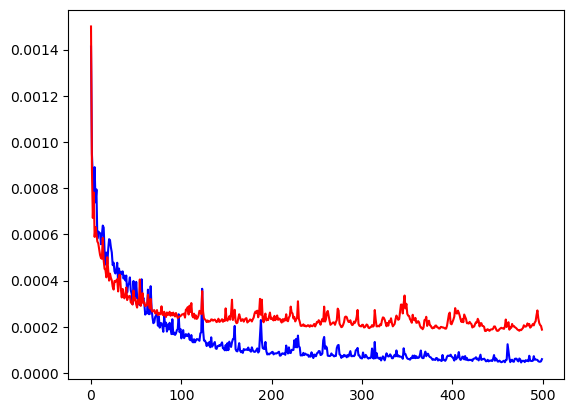

In [11]:
plt.plot(train_loss_list,c="blue")
plt.plot(val_loss_list,c="red")

In [12]:
# Load test dataloader from saved file (commented out - example usage)
# test_dataloader = torch.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv5-utb/xy_dataloader.pth")

# Initialize lists to store predictions and observations for both outputs
y_test_pred_list = []    # Store predictions for primary output (y1)
y_test_obs_list = []     # Store ground truth observations for primary output (y1)

y2_test_pred_list = []   # Store predictions for secondary output (y2)
y2_test_obs_list = []    # Store ground truth observations for secondary output (y2)

# Iterate through test dataset batches for model evaluation
for test_batch_x, test_batch_y, test_batch_y2 in test_dataloader:
    with torch.no_grad():  # Disable gradient computation for evaluation
        # Move batch data to appropriate device (GPU/CPU)
        test_batch_x = test_batch_x.to(device)
        
        # Denormalize target values using precomputed min-max values
        test_batch_y = (test_batch_y * (y1_max - y1_min) + y1_min).to(device)
        test_batch_y2 = (test_batch_y2 * (y2_max - y2_min) + y2_min).to(device)
        
        # Generate model predictions for both outputs
        y_test_pred, y2_test_pred = model(test_batch_x)
    
        # Denormalize model predictions to original scale
        y1_test_pred = ((y_test_pred) * (y1_max - y1_min) + y1_min)
        y2_test_pred = ((y2_test_pred) * (y2_max - y2_min) + y2_min)
        
        # Append predictions and observations to respective lists
        y_test_pred_list.append(y1_test_pred)
        y_test_obs_list.append(test_batch_y)
        
        y2_test_pred_list.append(y2_test_pred)
        y2_test_obs_list.append(test_batch_y2)

# Concatenate all batch predictions and observations into single tensors
y_test_pred_np = torch.cat(y_test_pred_list)  # All y1 predictions
y_test_obs_np = torch.cat(y_test_obs_list)    # All y1 observations

y2_test_pred_np = torch.cat(y2_test_pred_list)  # All y2 predictions
y2_test_obs_np = torch.cat(y2_test_obs_list)    # All y2 observations

# Save predictions and observations as numpy arrays for further analysis
np.save(f + "y_pred.npy", y_test_pred_np.cpu().detach().numpy())    # Save y1 predictions
np.save(f + "y_obs.npy", y_test_obs_np.cpu().detach().numpy())      # Save y1 observations
np.save(f + "y2_pred.npy", y2_test_pred_np.cpu().detach().numpy())  # Save y2 predictions
np.save(f + "y2_obs.npy", y2_test_obs_np.cpu().detach().numpy())    # Save y2 observations

# Import evaluation metrics from scikit-learn
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Prepare data for evaluation metrics calculation
y_pred = y_test_pred_np.cpu().detach().numpy()  # Convert y1 predictions to numpy
y_obs = y_test_obs_np.cpu().detach().numpy()    # Convert y1 observations to numpy

# Calculate R² score and Mean Squared Error for primary output (y1)
r1 = r2_score(y_obs.reshape(-1, 1), y_pred.reshape(-1, 1))
mse = mean_squared_error(y_obs.reshape(-1, 1), y_pred.reshape(-1, 1))

# Prepare data for secondary output (y2) evaluation
y_pred2 = y2_test_pred_np.cpu().detach().numpy()  # Convert y2 predictions to numpy
y_obs2 = y2_test_obs_np.cpu().detach().numpy()    # Convert y2 observations to numpy

# Calculate R² score and Mean Squared Error for secondary output (y2)
r2 = r2_score(y_obs2.reshape(-1, 1), y_pred2.reshape(-1, 1))
mse2 = mean_squared_error(y_obs2.reshape(-1, 1), y_pred2.reshape(-1, 1))

# Print evaluation results for both outputs
print("y1:", r1, mse, "y2:", r2, mse2)

y1: 0.8354750275611877 0.00014862425 y2: 0.4423128366470337 4.0844898e-05


In [13]:
# Initialize lists to store predictions and observations for the entire dataset (train + val + test)
y_xy_pred_list = []    # Store predictions for primary output (y1) on full dataset
y_xy_obs_list = []     # Store ground truth observations for primary output (y1) on full dataset

y2_xy_pred_list = []   # Store predictions for secondary output (y2) on full dataset
y2_xy_obs_list = []    # Store ground truth observations for secondary output (y2) on full dataset

# Iterate through the entire dataset (xy_dataloader contains all data)
for xy_batch_x, xy_batch_y, xy_batch_y2 in xy_dataloader:
    with torch.no_grad():  # Disable gradient computation for inference
        # Move batch data to appropriate device (GPU/CPU)
        xy_batch_x = xy_batch_x.to(device)
        
        # Denormalize target values using precomputed min-max values
        xy_batch_y = (xy_batch_y * (y1_max - y1_min) + y1_min).to(device)
        xy_batch_y2 = (xy_batch_y2 * (y2_max - y2_min) + y2_min).to(device)
        
        # Generate model predictions for both outputs on full dataset
        y_xy_pred, y2_xy_pred = model(xy_batch_x)
    
        # Denormalize model predictions to original scale
        y1_xy_pred = ((y_xy_pred) * (y1_max - y1_min) + y1_min)
        y2_xy_pred = ((y2_xy_pred) * (y2_max - y2_min) + y2_min)
        
        # Append predictions and observations to respective lists
        y_xy_pred_list.append(y1_xy_pred)
        y_xy_obs_list.append(xy_batch_y)
        
        y2_xy_pred_list.append(y2_xy_pred)
        y2_xy_obs_list.append(xy_batch_y2)

# Concatenate all batch predictions and observations into single tensors for full dataset
y_xy_pred_np = torch.cat(y_xy_pred_list)  # All y1 predictions for full dataset
y_xy_obs_np = torch.cat(y_xy_obs_list)    # All y1 observations for full dataset

y2_xy_pred_np = torch.cat(y2_xy_pred_list)  # All y2 predictions for full dataset
y2_xy_obs_np = torch.cat(y2_xy_obs_list)    # All y2 observations for full dataset

# Save predictions and observations for full dataset as numpy arrays
np.save(f + "y_xy_pred.npy", y_xy_pred_np.cpu().detach().numpy())    # Save y1 predictions for full dataset
np.save(f + "y_xy_obs.npy", y_xy_obs_np.cpu().detach().numpy())      # Save y1 observations for full dataset
np.save(f + "y2_xy_pred.npy", y2_xy_pred_np.cpu().detach().numpy())  # Save y2 predictions for full dataset
np.save(f + "y2_xy_obs.npy", y2_xy_obs_np.cpu().detach().numpy())    # Save y2 observations for full dataset

# Import evaluation metrics from scikit-learn
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Prepare data for evaluation metrics calculation on full dataset
y_pred = y_xy_pred_np.cpu().detach().numpy()  # Convert y1 predictions to numpy
y_obs = y_xy_obs_np.cpu().detach().numpy()    # Convert y1 observations to numpy

# Calculate R² score and Mean Squared Error for primary output (y1) on full dataset
r1 = r2_score(y_obs.reshape(-1, 1), y_pred.reshape(-1, 1))
mse = mean_squared_error(y_obs.reshape(-1, 1), y_pred.reshape(-1, 1))

# Prepare data for secondary output (y2) evaluation on full dataset
y_pred2 = y2_xy_pred_np.cpu().detach().numpy()  # Convert y2 predictions to numpy
y_obs2 = y2_xy_obs_np.cpu().detach().numpy()    # Convert y2 observations to numpy

# Calculate R² score and Mean Squared Error for secondary output (y2) on full dataset
r2 = r2_score(y_obs2.reshape(-1, 1), y_pred2.reshape(-1, 1))
mse2 = mean_squared_error(y_obs2.reshape(-1, 1), y_pred2.reshape(-1, 1))

# Print evaluation results for both outputs on full dataset
print("y1:", r1, mse, "y2:", r2, mse2)

/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


y1: 0.9096291661262512 8.242744e-05 y2: 0.4329889416694641 4.1389772e-05


In [14]:
# import numpy as np
# from captum.attr import IntegratedGradients
# from captum.attr import Occlusion

# x=xc#np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")
# ig = IntegratedGradients(model)
# baseline = torch.from_numpy(np.expand_dims(np.nanmean(x,axis=0),axis=0)).cuda().float()
# import torch

# igl=[];deltal=[]
# with torch.no_grad():
#     for i in range(1):
#         with torch.no_grad():
#             # x_input=torch.from_numpy(x[i:i+1,:,:,:,:]).cuda().float()
#             # x_input=torch.Tensor(x[i:i+1,:,:,:,:]).cuda().float()
#             attributions, delta = ig.attribute(x_input, baseline, target=0, return_convergence_delta=False)
#             igl.append(attributions.detach())
#             deltal.append(delta.detach())
#             # torch.cuda.memory_summary(device=device, abbreviated=False)
#             # model.cpu()
#             # torch.cuda.empty_cache()
      
# ig_tensor=torch.cat(igl, 0)	
# delta_tensor=torch.cat(deltal, 0)

In [15]:
# Function to compute Expected Gradients for model interpretability
def expected_gradients(model, data, baseline, n_iter, device):
    # Input validation checks
    assert isinstance(data, np.ndarray), "data should be np.ndarray type"
    assert data.ndim == 5, "Input data should have 5 dimensions: (n_batch, n_feat, h, w)"
    assert isinstance(baseline, np.ndarray), "baseline should be np.ndarray type"
    assert baseline.ndim == 5, "Baseline should have 5 dimensions: (n_batch, n_feat, h, w)"

    # Convert input data to PyTorch tensor and move to specified device
    input_x = torch.from_numpy(data).float().to(device)
    
    # Sample baseline points for each input instance
    replace = 1  # Always sample with replacement
    sample_idx = np.random.choice(baseline.shape[0], size=(input_x.shape[0], n_iter), replace=replace)
    print(sample_idx.shape)  # Debug: print sampling indices shape
    
    # Get sampled baseline points and convert to tensor
    sampled_baseline = torch.from_numpy(baseline[sample_idx]).float().cuda()
    print(sampled_baseline.shape)  # Debug: print sampled baseline shape

    # Create interpolation coefficients (alpha values between 0 and 1)
    alpha = np.linspace(0, 1, n_iter)
    alpha = torch.from_numpy(alpha).float().to(device)
    # Reshape alpha for broadcasting with input dimensions
    alpha = alpha.view(n_iter, *tuple(np.ones(baseline[0].ndim, dtype='int')))

    # Initialize list to store attribution maps for each input
    attributions = []
    
    # Process each input instance individually
    for i in range(input_x.shape[0]):
        # Get current input and corresponding baseline references
        x = input_x[i].unsqueeze(0)  # Add batch dimension
        ref = sampled_baseline[i]    # Sampled baseline for this input
        
        # Create interpolated points between baseline and input
        scaled_x = ref + alpha * (x - ref)
        
        # Initialize attribution tensor
        attribution = torch.zeros(*scaled_x.shape).to(device)
        
        # Compute gradients for each interpolated point
        for i in range(n_iter):
            part_scaled_x = scaled_x[i:i+1]
            part_scaled_x.requires_grad = True  # Enable gradient computation
            
            # Forward pass through model
            part_y_hat = model(part_scaled_x)
            
            # Compute gradients of output with respect to input
            attribution[i] = torch.autograd.grad(
                part_y_hat[0], part_scaled_x, 
                grad_outputs=torch.ones_like(part_y_hat[0])
            )[0]
        
        # Integrate gradients along the interpolation path
        integrated = attribution.sum(axis=0) / n_iter
        
        # Compute final attribution map
        ig = (x - ref).mean(axis=0) * integrated
        ig = ig.detach().cpu().numpy().squeeze()  # Convert to numpy and remove extra dimensions
        
        attributions.append(ig)
    
    # Convert list of attributions to numpy array
    attributions = np.array(attributions)

    return attributions 

# Load or use input data for explanation analysis
xc = x  # Using existing x data, alternative: np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")

# Initialize list to store expected gradients results
ael = []

# Compute Expected Gradients for different numbers of iterations (in descending order)
for i in [30, 20, 10]:
    # Calculate Expected Gradients attribution maps
    ae = expected_gradients(model=model, data=xc, n_iter=i, baseline=xc, device=device)
    
    # Save attribution maps to file
    np.save(f + "eg_" + str(i) + ".npy", ae)
    
    # Store results in list
    ael.append(ae)

(737, 30)
torch.Size([737, 30, 8, 216, 21, 21])
(737, 20)
torch.Size([737, 20, 8, 216, 21, 21])
(737, 10)
torch.Size([737, 10, 8, 216, 21, 21])


In [16]:
# from captum.attr import GradientShap
# import numpy as np

# gradient_shap = GradientShap(model)
# xc=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")
# # baselines = torch.randn(737, 8, 216, 11, 11).to(device)
# baselines =torch.from_numpy(xc).float().to(device)
# sg2=np.full((737, 8, 216, 11, 11),np.nan)
# for i in range(737):
#     with torch.no_grad():
#         x_input=torch.from_numpy(xc[i:i+1,:,:,:,:]).cuda().float().to(device)
#         attribution = gradient_shap.attribute(x_input, baselines,target=0)
#         sg2[i,:,:,:,:]=attribution.cpu()


In [17]:
torch.save(model,f+"model.pth")

In [18]:
# Model saving and evaluation section ----

# Define file path prefix for saving outputs
f = folder_path + "/"

# Load the trained model from saved file
model = torch.load(f + "model.pth").module  # Extract model from DataParallel wrapper

# Set device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the appropriate device
model.to(device)

# Set model to evaluation mode (disables dropout, batch norm uses running statistics)
model.eval()

# Load or use input data for explanation analysis
xc = x  # Using existing x data, alternative: np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")

# Initialize list to store expected gradients results
ael = []

# Compute Expected Gradients for different numbers of iterations
for i in [10, 20, 30]:
    # Calculate Expected Gradients - a model interpretability/explainability method
    # This measures the average sensitivity of predictions to input features
    ae = expected_gradients(model=model, data=xc, n_iter=i, baseline=xc, device=device)
    
    # Save Expected Gradients results to file
    np.save(f + "eg_" + str(i) + "_eval.npy", ae)
    
    # Store results in list for potential further analysis
    ael.append(ae)

(737, 10)
torch.Size([737, 10, 8, 216, 21, 21])
(737, 20)
torch.Size([737, 20, 8, 216, 21, 21])
(737, 30)
torch.Size([737, 30, 8, 216, 21, 21])


In [19]:
#-------------------------
# np.save(f+"shuffled_indices.npy",shuffled_indices)
# np.save(f+'ig.npy',ig_tensor.cpu())
# np.save(f+'delta.npy',delta_tensor.cpu())
# np.save(f+"sg_random_base.npy",sg)
# np.save(f+"sg_self_base.npy",sg2)
#-------------------------

#-------------------------


In [ ]:
# from plot import plot_mask_land
# import numpy as np
# from matplotlib.colors import CenteredNorm,TwoSlopeNorm
# # eg=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/63/eg_10.npy")
# a,b=plot_mask_land(ael[1],norm=TwoSlopeNorm(vmin=-0.0001,vcenter=0., vmax=0.0001),path=None)#,ig_tensor.cpu()  

In [ ]:
# from plot import plot_mask_land
# from matplotlib.colors import CenteredNorm,TwoSlopeNorm
# a,b=plot_mask_land(ig_tensor.cpu(),norm=TwoSlopeNorm(vmin=-0.000005,vcenter=0., vmax=0.000005),path=None)#

In [ ]:
# y_xy_pred_list=[]
# y_xy_obs_list=[]

# y2_xy_pred_list=[]
# y2_xy_obs_list=[]


# for xy_batch_x, xy_batch_y, xy_batch_y2 in xy_dataloader:
#     with torch.no_grad():
     

#         xy_batch_x=xy_batch_x.to(device)
#         xy_batch_y=(xy_batch_y*(y1_max-y1_min)+y1_min).to(device)
#         xy_batch_y2=(xy_batch_y2*(y2_max-y2_min)+y2_min).to(device)
#         y_xy_pred,y2_xy_pred = model(xy_batch_x)
    
#         y1_xy_pred=((y_xy_pred)*(y1_max-y1_min)+y1_min)
#         y2_xy_pred=((y2_xy_pred)*(y2_max-y2_min)+y2_min)
#         y_xy_pred_list.append(y1_xy_pred)
#         y_xy_obs_list.append(xy_batch_y)
        
#         y2_xy_pred_list.append(y2_xy_pred)
#         y2_xy_obs_list.append(xy_batch_y2)

 


# y_xy_pred_np=torch.cat(y_xy_pred_list)
# y_xy_obs_np=torch.cat(y_xy_obs_list)

# y2_xy_pred_np=torch.cat(y2_xy_pred_list)
# y2_xy_obs_np=torch.cat(y2_xy_obs_list)

# from sklearn.metrics import r2_score
# from sklearn.metrics import mean_squared_error
# y_pred=y_xy_pred_np.cpu().detach().numpy()
# y_obs= y_xy_obs_np.cpu().detach().numpy()

In [24]:
# varlist_name=["lai_080","lai_085","lai_090","lai_095","lai_100","lai_105","lai_110","lai_115","lai_120"]
# varlist=[0.8,0.85,0.9,0.95,1,1.05,1.1,1.15,1.2]
# for i in range(9):
#     test_dataloader=torch.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/888/xy_dataloader.pth")

    
#     y_test_pred_list=[]
#     y_test_obs_list=[]
    
#     y2_test_pred_list=[]
#     y2_test_obs_list=[]
    
    
#     for test_batch_x, test_batch_y, test_batch_y2 in test_dataloader:
#         with torch.no_grad():
         
#             test_batch_x=test_batch_x.to(device)
#             test_batch_x[:,0,:,:,:]=test_batch_x[:,0,:,:,:]*varlist[i]

#             test_batch_y=(test_batch_y*(y1_max-y1_min)+y1_min).to(device)
#             test_batch_y2=(test_batch_y2*(y2_max-y2_min)+y2_min).to(device)
#             y_test_pred,y2_test_pred = model(test_batch_x)
        
#             y1_test_pred=((y_test_pred)*(y1_max-y1_min)+y1_min)
#             y2_test_pred=((y2_test_pred)*(y2_max-y2_min)+y2_min)
#             y_test_pred_list.append(y1_test_pred)
#             y_test_obs_list.append(test_batch_y)
            
#             y2_test_pred_list.append(y2_test_pred)
#             y2_test_obs_list.append(test_batch_y2)
    
#     y_test_pred_np=torch.cat(y_test_pred_list).cpu()
#     y_test_obs_np=torch.cat(y_test_obs_list).cpu()

#     y2_test_pred_np=torch.cat(y2_test_pred_list).cpu()
#     y2_test_obs_np=torch.cat(y2_test_obs_list).cpu()

#     np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/888/permute_lai/"+varlist_name[i]+"_y_pred.npy",y_test_pred_np)
#     np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/888/permute_lai/"+varlist_name[i]+"_y_obs.npy",y_test_obs_np)
#     np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/888/permute_lai/"+varlist_name[i]+"_y2_pred.npy",y2_test_pred_np)
#     np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/888/permute_lai/"+varlist_name[i]+"_y2_obs.npy",y2_test_obs_np)

In [ ]:
# import numpy as np
# torch.manual_seed(123)
# np.random.seed(123)
# x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")

# occlusion = Occlusion(model)
# for i in range(737):
#     with torch.no_grad():
#         x_input=torch.from_numpy(x[i:i+1,:,:,:,:]).cuda().float().to(device)
#         attributions_occ = occlusion.attribute(x_input,
#                                            target=0,
#                                            strides=(1,1, 3, 3),
#                                            sliding_window_shapes=(1,1,3, 3),
#                                            baselines=0)
#         np.save('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv5-utb-3to1_2/og_'+str(i)+'.npy',attributions_occ.cpu())
#         print(i)
